In [ ]:
#add libraries for tabular and vector data and for plotting
import pandas as pd #tab
import geopandas as gpd #vector
import matplotlib.pyplot as plt #basic plotting
import seaborn as sns #advanced plotting
#for jenks classification
!pip install jenkspy
import jenkspy
import numpy as np
#mount the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


,COUNTY,geometry,area_acres
0,LARIMER,"POLYGON ((-105.05673 40.34929, -105.05664 40.3...",1.686788e+06
1,LAS ANIMAS,"POLYGON ((-104.14319 37.75834, -104.14408 37.7...",3.058840e+06
2,FREMONT,"POLYGON ((-105.3689 38.25941, -105.36889 38.25...",9.817170e+05
3,GUNNISON,"POLYGON ((-106.7997 38.97966, -106.80041 38.97...",2.086049e+06
4,CONEJOS,"POLYGON ((-106.14888 37.40111, -106.15066 37.4...",8.269923e+05


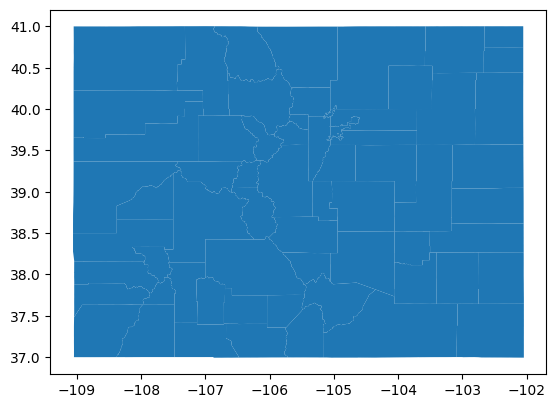

In [ ]:
#Import county boundary polygons file
file = '/content/drive/My Drive/ESIIL2025MSU/Project Data/Colorado_County_Boundaries.geojson'
#define the variable
counties_gdf = gpd.read_file(file)
#select relevent columns
counties_gdf = counties_gdf[['COUNTY','geometry']]
#project the data for area calculation
counties_gdf = counties_gdf.to_crs(epsg=2232)#epsg integer code for "CO Central Projection"
#calculate area of each polygon in acres
counties_gdf['area_acres'] = counties_gdf.area/43560
#reproject for web display
counties_gdf = counties_gdf.to_crs(epsg=4326)
#plot it and show the data
counties_gdf.plot()
counties_gdf.head()

In [ ]:
#add data for all land (area) in farms with irrigation systems
from google.colab import drive
file = '/content/drive/MyDrive/ESIIL2025MSU/Project Data/Acre_AgCensus.csv'
irrigatedacres_df = pd.read_csv(file)
#show me the data
print(irrigatedacres_df.dtypes)
irrigatedacres_df.head()

County                      object
Year                        object
all_irrigatedfarms_acres    object
with_harvestland_acres      object
with_othercropland_acres    object
with_pastureland_acres      object
all_irrigatedland_acres     object
irrigatedcrop_acre          object
irrigated_pasture_acre      object
dtype: object


,County,Year,all_irrigatedfarms_acres,with_harvestland_acres,with_othercropland_acres,with_pastureland_acres,all_irrigatedland_acres,irrigatedcrop_acre,irrigated_pasture_acre
0,Colorado,"1,982",17351278,3435646,1103227,11591831,3200942,2656328,544614
1,Adams,"1,982",195521,77146,62103,49258,33218,31529,1689
2,Alamosa,"1,982",212918,69945,8554,126827,96880,69515,27365
3,Arapahoe,"1,982",95832,15283,17460,61180,3883,3769,114
4,Archuleta,"1,982",95642,5080,707,77230,10837,4399,6438


In [ ]:
#Fix the data to join it and display it
#Change the key attribute column name
irrigatedacres_df.rename(columns={'Unnamed: 0':'County'}, inplace=True)
#Capitalize all character in the Column 'County'
irrigatedacres_df['County'] = irrigatedacres_df['County'].str.upper()
#Convert string to numeric
#Columns to convert to numeric 64bit integer
cols_to_convert = [
    'Year',
    'all_irrigatedfarms_acres',
    'with_harvestland_acres',
    'with_othercropland_acres',
    'with_pastureland_acres',
    'all_irrigatedland_acres',
    'irrigatedcrop_acre',
    'irrigated_pasture_acre'
]
for col in cols_to_convert:
    # Replace 'Withheld' with NaN
    irrigatedacres_df[col] = irrigatedacres_df[col].replace('Withheld', pd.NA)
    # Remove commas and convert to numeric, coercing errors to NaN
    irrigatedacres_df[col] = irrigatedacres_df[col].astype(str).str.replace(',', '', regex=False)
    irrigatedacres_df[col] = pd.to_numeric(irrigatedacres_df[col], errors='coerce')
    # Convert to nullable integer type
    irrigatedacres_df[col] = irrigatedacres_df[col].astype('Int64')

#Create state df
co_ia_df = irrigatedacres_df[irrigatedacres_df.County == 'COLORADO']
#delete the record COLORADO from the county df
irrigatedacres_df = irrigatedacres_df[irrigatedacres_df.County != 'COLORADO']

#show me the data
display(co_ia_df.head())
display(irrigatedacres_df.head())
print(irrigatedacres_df.dtypes)

,County,Year,all_irrigatedfarms_acres,with_harvestland_acres,with_othercropland_acres,with_pastureland_acres,all_irrigatedland_acres,irrigatedcrop_acre,irrigated_pasture_acre
0,COLORADO,1982,17351278,3435646,1103227,11591831,3200942,2656328,544614
65,COLORADO,1987,16729869,3146213,1372026,10932828,3013773,2442358,571415
130,COLORADO,1992,16647647,3390951,1206604,10841095,3169839,2649111,520728
195,COLORADO,1997,16265182,3618930,1171343,9930005,3430129,2762068,668061
260,COLORADO,2002,12864432,2840736,1690786,7039625,2590654,2178748,411906


,County,Year,all_irrigatedfarms_acres,with_harvestland_acres,with_othercropland_acres,with_pastureland_acres,all_irrigatedland_acres,irrigatedcrop_acre,irrigated_pasture_acre
1,ADAMS,1982,195521,77146,62103,49258,33218,31529,1689
2,ALAMOSA,1982,212918,69945,8554,126827,96880,69515,27365
3,ARAPAHOE,1982,95832,15283,17460,61180,3883,3769,114
4,ARCHULETA,1982,95642,5080,707,77230,10837,4399,6438
5,BACA,1982,333830,126068,73591,131330,58702,57293,1409


County                      object
Year                         Int64
all_irrigatedfarms_acres     Int64
with_harvestland_acres       Int64
with_othercropland_acres     Int64
with_pastureland_acres       Int64
all_irrigatedland_acres      Int64
irrigatedcrop_acre           Int64
irrigated_pasture_acre       Int64
dtype: object


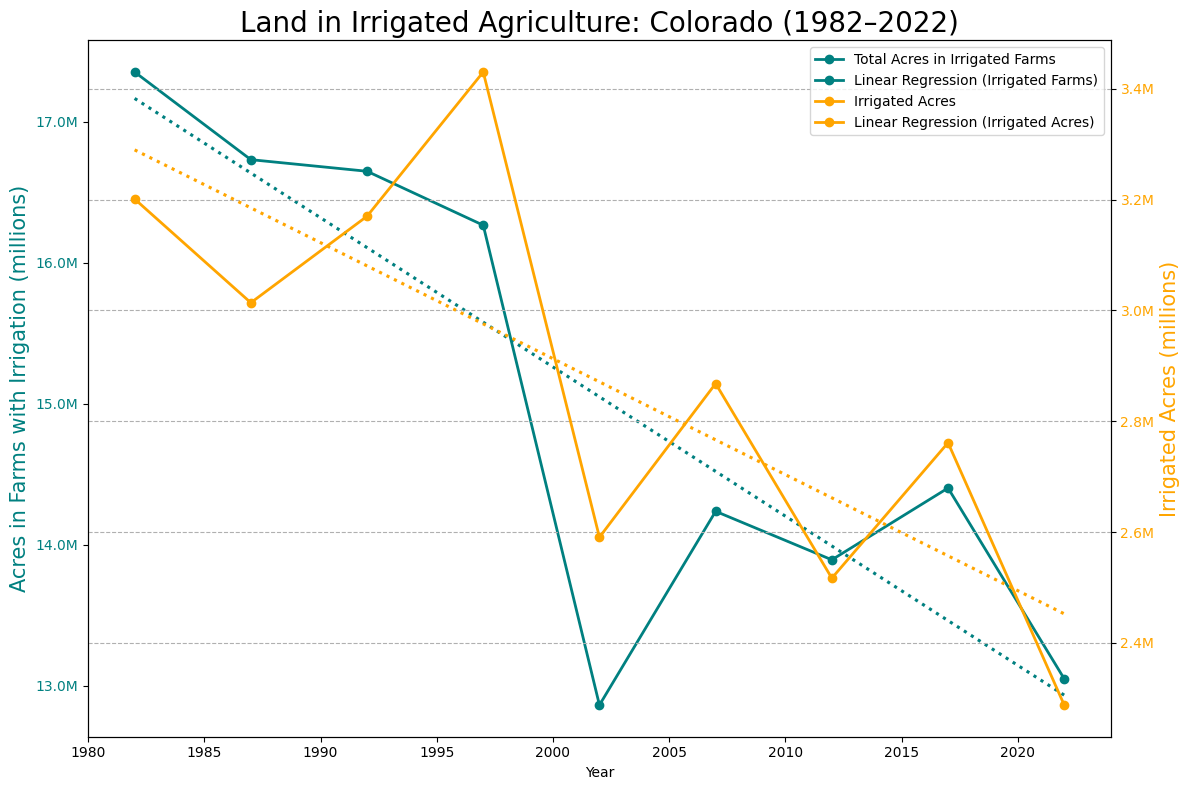

In [ ]:
# create a plot of co_ia_df with the field 'all_irrigatedfarms_acres' and "all_irrigatedland_acres' on a secondary axes
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

plt.figure(figsize=(12, 8)) # Increased figure width

# Plot all_irrigatedfarms_acres
line1, = plt.plot(co_ia_df['Year'], co_ia_df['all_irrigatedfarms_acres'], marker='o',
                  color='teal', linewidth=2, label='Acres in Farms with Irrigation')
plt.tick_params(axis='y', labelcolor='teal')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
# Add linear regression for all_irrigatedfarms_acres using seaborn
reg_line1 = sns.regplot(x='Year', y='all_irrigatedfarms_acres',data=co_ia_df,scatter=False,color='teal', ax=plt.gca(), line_kws={'linestyle': 'dotted', 'label': 'Linear Regression (Irrigated Farms)'}, ci=None)

# Set primary y-axis label
plt.ylabel('Acres in Farms with Irrigation (millions)', color='teal', fontsize=15)


# Create the secondary y-axis
ax2 = plt.twinx()
# Plot all_irrigatedland_acres on the second y-axis
line2, = ax2.plot(co_ia_df['Year'], co_ia_df['all_irrigatedland_acres'], marker='o', color='orange', linewidth=2, label='Irrigated Acres')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
# Add linear regression for all_irrigatedland_acres using seaborn
reg_line2 = sns.regplot(x='Year', y='all_irrigatedland_acres', data=co_ia_df, scatter=False, color='orange', ax=plt.gca(), line_kws={'linestyle': 'dotted', 'label': 'Linear Regression (Irrigated Acres)'}, ci=None)

# Customize the plot
plt.title('Land in Irrigated Agriculture: Colorado (1982–2022)', fontsize=20)
plt.xlabel('Year', fontsize=15)
ax2.set_ylabel('Irrigated Acres (millions)', color='orange', fontsize=15)
plt.grid(True, linestyle='--')

# Add a single legend for both lines and regression lines
lines = [line1, reg_line1.get_lines()[0], line2, reg_line2.get_lines()[0]] # Get the line artists from regplot
labels = ['Total Acres in Irrigated Farms', 'Linear Regression (Irrigated Farms)', 'Irrigated Acres', 'Linear Regression (Irrigated Acres)']
ax2.legend(lines, labels, loc='upper right')

plt.tight_layout()

# Save the plot before showing it
plt.savefig('irrigated_acres_plot.jpeg', dpi=500)

# Show the plot
plt.show()

In [ ]:
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
import numpy as np

# Calculate linear regression for 'all_irrigatedfarms_acres'
model_farms = LinearRegression().fit(co_ia_df[['Year']], co_ia_df['all_irrigatedfarms_acres'])
year_range = np.array([co_ia_df['Year'].min(), co_ia_df['Year'].max()]).reshape(-1, 1)
predicted_farms = model_farms.predict(year_range)

# Calculate linear regression for 'all_irrigatedland_acres'
model_land = LinearRegression().fit(co_ia_df[['Year']], co_ia_df['all_irrigatedland_acres'])
predicted_land = model_land.predict(year_range)

# Create interactive plot using Plotly
fig = go.Figure()

# Add trace for 'all_irrigatedfarms_acres'
fig.add_trace(go.Scatter(x=co_ia_df['Year'], y=co_ia_df['all_irrigatedfarms_acres'],
                         mode='lines+markers',
                         name='Acres in Farms with Irrigation Systems',
                         yaxis='y1',
                         marker=dict(color='teal')))

# Add linear regression for 'all_irrigatedfarms_acres'
fig.add_trace(go.Scatter(x=year_range.flatten(), y=predicted_farms,
                         mode='lines',
                         name='Linear Regression (Irrigated Farms)',
                         line=dict(color='teal', dash='dot'),
                         yaxis='y1'))


# Add trace for 'all_irrigatedland_acres'
fig.add_trace(go.Scatter(x=co_ia_df['Year'], y=co_ia_df['all_irrigatedland_acres'],
                         mode='lines+markers',
                         name='Irrigated Acres',
                         yaxis='y2',
                         marker=dict(color='orange')))

# Add linear regression for 'all_irrigatedland_acres'
fig.add_trace(go.Scatter(x=year_range.flatten(), y=predicted_land,
                         mode='lines',
                         name='Linear Regression (Irrigated Acres)',
                         line=dict(color='orange', dash='dot'),
                         yaxis='y2'))

# Update layout for dual y-axes and formatting
fig.update_layout(
    title='Land in Irrigated Agriculture: Colorado (1982–2022)',
    xaxis_title='Year',
    yaxis=dict(
        title='Acres in Farms with Irrigation Systems (millions)',
        titlefont=dict(color='teal'),
        tickfont=dict(color='teal'),
        side='left',
        showgrid=True, # Show grid lines for the first y-axis
        gridcolor='lightgray' # Set grid color to light gray
    ),
    yaxis2=dict(
        title='Irrigated Acres (millions)',
        titlefont=dict(color='orange'),
        tickfont=dict(color='orange'),
        overlaying='y',
        side='right',
        showgrid=True, # Show grid lines for the second y-axis
        gridcolor='lightgray' # Set grid color to light gray
    ),
    xaxis=dict(
        showgrid=True, # Show grid lines for the x-axis
        gridcolor='lightgray' # Set grid color to light gray
    ),
    hovermode='x unified',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    plot_bgcolor='rgba(0,0,0,0)'   # Set plot background to transparent
)

# Save the interactive plot as an HTML file
fig.write_html("interactive_irrigated_acres_plot.html")

# Display the plot in the notebook
fig.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [ ]:
#Time the join the census with the map
norm_irrigatedacres_gdf = counties_gdf.merge(irrigatedacres_df, left_on='COUNTY'
, right_on='County')
#pull out the necessary columns
norm_irrigatedacres_gdf = norm_irrigatedacres_gdf[['COUNTY','Year',
                                                   'all_irrigatedfarms_acres',
                                                   'all_irrigatedland_acres',
                                                   'area_acres','geometry']]
#create normalized fields
norm_irrigatedacres_gdf['norm_allacres'] = norm_irrigatedacres_gdf['all_irrigatedfarms_acres']/norm_irrigatedacres_gdf['area_acres'] * 100
norm_irrigatedacres_gdf['norm_irrigatedacres'] = norm_irrigatedacres_gdf['all_irrigatedland_acres']/norm_irrigatedacres_gdf['area_acres'] * 100
#create ratio fields
norm_irrigatedacres_gdf['irrigated_ratio'] = norm_irrigatedacres_gdf['all_irrigatedland_acres']/norm_irrigatedacres_gdf['all_irrigatedfarms_acres'] * 100
#show me the data
#save norm_irrigatedacres_gdf as a geojson
norm_irrigatedacres_gdf.to_file('/content/drive/MyDrive/ESIIL2025MSU/Project Data/norm_irrigatedacres_gdf.geojson', driver='GeoJSON')
norm_irrigatedacres_gdf

,COUNTY,Year,all_irrigatedfarms_acres,all_irrigatedland_acres,area_acres,geometry,norm_allacres,norm_irrigatedacres,irrigated_ratio
0,LARIMER,1982,355497,104534,1.686788e+06,"POLYGON ((-105.05673 40.34929, -105.05664 40.3...",21.075382,6.197222,29.40503
1,LARIMER,1987,379553,79870,1.686788e+06,"POLYGON ((-105.05673 40.34929, -105.05664 40.3...",22.501524,4.735035,21.043174
2,LARIMER,1992,303816,82724,1.686788e+06,"POLYGON ((-105.05673 40.34929, -105.05664 40.3...",18.011511,4.904232,27.228322
3,LARIMER,1997,338584,77695,1.686788e+06,"POLYGON ((-105.05673 40.34929, -105.05664 40.3...",20.072707,4.606092,22.947038
4,LARIMER,2002,267870,58837,1.686788e+06,"POLYGON ((-105.05673 40.34929, -105.05664 40.3...",15.880479,3.488109,21.964759
...,...,...,...,...,...,...,...,...,...
571,HUERFANO,2002,110747,6381,1.020182e+06,"POLYGON ((-105.01374 37.88128, -105.01374 37.8...",10.855616,0.625477,5.761781
572,HUERFANO,2007,191337,13889,1.020182e+06,"POLYGON ((-105.01374 37.88128, -105.01374 37.8...",18.75519,1.361424,7.25892
573,HUERFANO,2012,197823,11651,1.020182e+06,"POLYGON ((-105.01374 37.88128, -105.01374 37.8...",19.390959,1.142052,5.889608
574,HUERFANO,2017,195205,8573,1.020182e+06,"POLYGON ((-105.01374 37.88128, -105.01374 37.8...",19.134338,0.840341,4.391793


In [ ]:
# Calculate max 'all_irrigatedland_acres' for each county where year < 2000
max_pre2k = irrigatedacres_df[irrigatedacres_df['Year'] < 2000].groupby('County')['all_irrigatedland_acres'].max()
# Calculate min 'all_irrigatedland_acres' for each county where year > 2000
min_post2k = irrigatedacres_df[irrigatedacres_df['Year'] > 2000].groupby('County')['all_irrigatedland_acres'].min()
# Combine the max and min values into a new DataFrame
ia_pctchange_df = pd.DataFrame({
    'max_pre_2000': max_pre2k,
    'min_post_2000': min_post2k
})

# Calculate the percent change
# Handle cases where max_pre_2000 might be 0 or NaN to avoid division errors
ia_pctchange_df['ia_pctchange'] = ((ia_pctchange_df['min_post_2000'] - ia_pctchange_df['max_pre_2000']) / ia_pctchange_df['max_pre_2000']) * 100

# Reset index to make County a column
ia_pctchange_df = ia_pctchange_df.reset_index()
#merge with county geometry
pctchange_gdf = counties_gdf.merge(ia_pctchange_df, left_on='COUNTY', right_on='County')
#drop unnecessary columns
pctchange_gdf = pctchange_gdf.drop(columns=['max_pre_2000', 'min_post_2000', 'County', 'area_acres'])

# Display the new DataFrame
# display(pctchange_gdf.head())
display(ia_pctchange_df)

,County,max_pre_2000,min_post_2000,ia_pctchange
0,ADAMS,33218,12101,-63.570956
1,ALAMOSA,108029,57143,-47.104018
2,ARAPAHOE,3901,987,-74.698795
3,ARCHULETA,16764,7515,-55.171797
4,BACA,65068,40768,-37.345546
...,...,...,...,...
59,SUMMIT,10939,3674,-66.413749
60,TELLER,1646,444,-73.025516
61,WASHINGTON,55568,29990,-46.030089
62,WELD,407293,274813,-32.526952


In [ ]:
#save the file
pctchange_gdf.to_file('/content/drive/MyDrive/ESIIL2025MSU/Project Data/pctchange_gdf.geojson', driver='GeoJSON')

In [ ]:
# calculate jenks classification for ia_pctchange with 7 bins

# Drop rows where 'ia_pctchange' is NaN or infinite before calculating jenks breaks
ia_pctchange_clean = pctchange_gdf['ia_pctchange'].dropna().replace([np.inf, -np.inf], np.nan).dropna()

# Convert the cleaned Series to a numpy array and ensure all values are finite
ia_pctchange_finite = ia_pctchange_clean[np.isfinite(ia_pctchange_clean)].to_numpy()

# Calculate Jenks natural breaks
breaks = jenkspy.jenks_breaks(ia_pctchange_finite, n_classes=5)

print("Jenks breaks for ia_pctchange:", breaks)

Jenks breaks for ia_pctchange: [np.float64(-94.3820224719101), np.float64(-80.03927396242437), np.float64(-60.16801394832778), np.float64(-42.8727665449972), np.float64(-28.197115384615383), np.float64(-5.541972290138549)]


In [ ]:
# create a new geodataframe filtered for years before 2000
pre2k = norm_irrigatedacres_gdf[norm_irrigatedacres_gdf['Year'] < 2000].copy()
# Calculate the average for each county for the relevant columns
pre2k = pre2k.groupby('COUNTY').agg(
    NIA_mean=('norm_irrigatedacres', 'mean'),
).reset_index()
#merge with county geometry and drop unnecessary fields
pre2k = counties_gdf.merge(pre2k, left_on='COUNTY', right_on='COUNTY')
pre2k = pre2k.drop(columns=['area_acres'])

#now for post 2000
post2k = norm_irrigatedacres_gdf[norm_irrigatedacres_gdf['Year'] >= 2000].copy()
post2k = post2k.groupby('COUNTY').agg(
    NIA_mean=('norm_irrigatedacres', 'mean'),
).reset_index()
post2k = counties_gdf.merge(post2k, left_on='COUNTY', right_on='COUNTY')
post2k = post2k.drop(columns=['area_acres'])

display(post2k.head())
display(pre2k.head())

,COUNTY,geometry,NIA_mean
0,LARIMER,"POLYGON ((-105.05673 40.34929, -105.05664 40.3...",3.586948
1,LAS ANIMAS,"POLYGON ((-104.14319 37.75834, -104.14408 37.7...",0.559853
2,FREMONT,"POLYGON ((-105.3689 38.25941, -105.36889 38.25...",1.055946
3,GUNNISON,"POLYGON ((-106.7997 38.97966, -106.80041 38.97...",2.207311
4,CONEJOS,"POLYGON ((-106.14888 37.40111, -106.15066 37.4...",11.582864


,COUNTY,geometry,NIA_mean
0,LARIMER,"POLYGON ((-105.05673 40.34929, -105.05664 40.3...",5.110645
1,LAS ANIMAS,"POLYGON ((-104.14319 37.75834, -104.14408 37.7...",0.861152
2,FREMONT,"POLYGON ((-105.3689 38.25941, -105.36889 38.25...",1.387543
3,GUNNISON,"POLYGON ((-106.7997 38.97966, -106.80041 38.97...",2.384088
4,CONEJOS,"POLYGON ((-106.14888 37.40111, -106.15066 37.4...",14.293905


In [ ]:
# append pre2k_list to post2k_list
# Convert NIA_mean columns to float to handle pd.NA before creating list
nia_list = post2k['NIA_mean'].astype(float).tolist() + pre2k['NIA_mean'].astype(float).tolist()
print(nia_list)

[3.586947637508687, 0.5598528150702564, 1.0559458129320416, 2.2073112881732047, 11.58286448834346, 1.1520595600844856, 5.545818804897552, 5.833342878584595, 1.4936255336763378, 2.7173867291903173, 1.3396909548075269, 1.1143214642980248, 2.2931319862890533, 3.8202807390669156, 2.5644921789892896, 0.6661285164859213, 15.087786703928767, 0.8093697761580808, 8.068157152545862, 4.834782222968933, 2.134211652265686, 13.157578475629697, 8.654725863542275, 4.55480187981619, 0.294396099814917, 0.46506133859180016, 0.41529845096561796, 1.1516336547852242, 10.669999214376434, 1.3990794715157133, 16.98304805391673, 17.29166649525812, 2.8004058959901337, 3.143820006363127, 4.882565852704611, 0.43561356436255616, 1.1522038902496452, 15.832816812817953, 1.2949433003275455, 8.205058238917578, 3.080846497267042, 3.0012965517937995, 8.515125789731043, 0.06844543014437357, 0.8405583977823043, 0.27772697748975816, 6.109838328414499, 0.26570485249889353, 2.0066058736534145, 0.2930668951001346, 7.0136191172

In [ ]:
#calculate jenks classification for nia_list
# Convert nia_list to a numpy array of floats (pd.NA is already converted to np.nan in the previous cell)
nia_array = np.array(nia_list, dtype=float)

# Drop NaN values before calculating Jenks breaks
breaks = jenkspy.jenks_breaks(nia_array[~np.isnan(nia_array)], n_classes=6) # Calculate Jenks breaks for 5 classes
print("Jenks Classification Breaks:", breaks)

Jenks Classification Breaks: [np.float64(0.0), np.float64(1.6264176470854195), np.float64(4.180785409376989), np.float64(7.421256227757052), np.float64(11.58286448834346), np.float64(15.832816812817953), np.float64(22.038599462044726)]


In [ ]:
# save the data
pre2k.to_file('/content/drive/MyDrive/ESIIL2025MSU/Project Data/pre2k.geojson', driver='GeoJSON')
post2k.to_file('/content/drive/MyDrive/ESIIL2025MSU/Project Data/post2k.geojson', driver='GeoJSON')

In [ ]:
# plot an interactive map of norm_irrigatedacres by county with a slider for years

!pip install ipywidgets
!pip install folium
!pip install branca

import folium
from branca.colormap import linear
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# Get the unique years from the data
years = sorted(norm_irrigatedacres_gdf['Year'].unique())

# Calculate global min/max for consistent colormap across years
global_min_norm_irrigatedacres = norm_irrigatedacres_gdf['norm_irrigatedacres'].min()
global_max_norm_irrigatedacres = norm_irrigatedacres_gdf['norm_irrigatedacres'].max()


# Create a slider widget for the years
year_slider = widgets.SelectionSlider(
    options=years,
    value=years[0],
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True
)

# Function to update the map based on the selected year
def update_map(year):
    # Filter data for the selected year
    gdf_year = norm_irrigatedacres_gdf[norm_irrigatedacres_gdf['Year'] == year]

    # Drop rows where 'norm_irrigatedacres' is NaN
    gdf_year = gdf_year.dropna(subset=['norm_irrigatedacres'])

    # Create a Folium map
    m = folium.Map(location=[39.0, -105.5], zoom_start=7) # Centered over Colorado

    # Define a color map using global min/max
    # Handle the case where min/max might be the same or the data is empty
    min_val = global_min_norm_irrigatedacres
    max_val = global_max_norm_irrigatedacres


    if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
        # Create a default map or handle this scenario appropriately
        folium.Marker(location=[39.0, -105.5], popup="No data for this year").add_to(m)
        display(m)
        return

    colormap = linear.YlOrRd_09.scale(min_val, max_val)


    # Add counties with color based on irrigated acres
    folium.GeoJson(
        gdf_year,
        style_function=lambda feature: {
            'fillColor': colormap(feature['properties']['norm_irrigatedacres']),
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        },
        tooltip=folium.features.GeoJsonTooltip(
            fields=['COUNTY', 'norm_irrigatedacres'],
            aliases=['County:','Percent of Land Irrigated:'],
            localize=True,
            sticky=False,
            labels=True,
            max_width=600,
        )
    ).add_to(m)

    # Add the colormap to the map
    colormap.caption = 'Percent of Land Irrigated by County'
    m.add_child(colormap)

    # Display the map
    display(m)
    #download the interactive map
    m.save('interactive_map.html')

# Connect the slider to the update function
widgets.interactive(update_map, year=year_slider)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.8 MB/s eta 0:00:00


interactive(children=(SelectionSlider(continuous_update=False, description='Year:', options=(np.int64(1982), n…